IMPORTS

In [54]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

PREPROCESSING

In [55]:
features = [
    "Income",
    "Age",
    "Dependents",
    "Occupation",
    "City_Tier",
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous"
]

In [56]:
df = pd.read_csv("../data/spending_habit_and_potential_savings_dataset.csv")
X = df[features]
y = df["Desired_Savings"]

SPLITTING CATEGORICAL AND NUMERICAL COLUMNS 

In [57]:
categorical_cols = [
    "Occupation",
    "City_Tier"
]
numerical_cols = [
    "Income",
    "Age",
    "Dependents",
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous"
]

SPLITTING TEST AND TRAIN SET

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

ENCODING CATEGORIAL VALUES AND SCALLING NUMERICAL VALUES

CHECKING MISSING DATA , IF YES WE NEED TO HANDLE IT.

In [59]:

# from sklearn.preprocessing import OneHotEncoder, StandardScaler

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", StandardScaler(), numerical_cols),
#         ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
#     ]
# )
# x_train = preprocessor.fit_transform(X_train)
# x_test = preprocessor.transform(X_test)

In [60]:
df.isnull().sum()

Income                             0
Age                                0
Dependents                         0
Occupation                         0
City_Tier                          0
Rent                               0
Loan_Repayment                     0
Insurance                          0
Groceries                          0
Transport                          0
Eating_Out                         0
Entertainment                      0
Utilities                          0
Healthcare                         0
Education                          0
Miscellaneous                      0
Desired_Savings_Percentage         0
Desired_Savings                    0
Disposable_Income                  0
Potential_Savings_Groceries        0
Potential_Savings_Transport        0
Potential_Savings_Eating_Out       0
Potential_Savings_Entertainment    0
Potential_Savings_Utilities        0
Potential_Savings_Healthcare       0
Potential_Savings_Education        0
Potential_Savings_Miscellaneous    0
d

PIPELINE

LINEAR REGRESSION MODEL

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_cols),
        ("cat", cat_transformer, categorical_cols)
    ]
)

In [62]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

LINEAR REGRESSION MODEL

In [ ]:
# model = LinearRegression()
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

ValueError: could not convert string to float: 'Student'

RANDOM FOREST

In [ ]:

# from sklearn.ensemble import RandomForestRegressor


# regressor = RandomForestRegressor(n_estimators=100, random_state=42)
# regressor.fit(x_train, y_train)

# y_pred_random_forest = regressor.predict(x_test)

POLYNOMIAL REGRESSION

In [ ]:
# from sklearn.preprocessing import PolynomialFeatures

# poly = PolynomialFeatures(
#     degree=2,
#     include_bias=False
# )

# x_train_poly = poly.fit_transform(x_train)
# x_test_poly = poly.transform(x_test)
# model_poly = LinearRegression()
# model_poly.fit(x_train_poly, y_train)
# y_pred_poly = model_poly.predict(x_test_poly)

SVR

In [ ]:
# from sklearn.svm import SVR

# svr_model = SVR()

# svr_model.fit(x_train, y_train)

# y_pred_svr = svr_model.predict(x_test)


DECISION TREE

In [ ]:
# from sklearn.tree import DecisionTreeRegressor

# dt_model = DecisionTreeRegressor(random_state=42)

# dt_model.fit(x_train, y_train)

# y_pred_dt = dt_model.predict(x_test)


R-SQUARE TEST RESULTS

In [ ]:
from sklearn.metrics import r2_score

print("R^2 Score:", r2_score(y_test, y_pred))

# print("R^2 Score Random Forest:", r2_score(y_test, y_pred_random_forest))
# print("R^2 Score Decision Tree:", r2_score(y_test, y_pred_dt))
# print("R^2 Score SVR:", r2_score(y_test, y_pred_svr))
# print("R^2 Score Polynomial Regression:", r2_score(y_test, y_pred_poly))

# R^2 Score: 0.9281676256211934
# R^2 Score Random Forest: 0.908368059278916
# R^2 Score Decision Tree: 0.8844702715549696
# R^2 Score SVR: 0.052605367270414094
# R^2 Score Polynomial Regression: 0.4371490150952484

R^2 Score: 0.9281676256211934


MANUAL INPUT

In [ ]:
sample_data = pd.DataFrame([{
    "Income": 50000,
    "Age": 25,
    "Dependents": 1,
    "Occupation": "Professional",
    "City_Tier": "Tier_1",
    "Rent": 15000,
    "Loan_Repayment": 3000,
    "Insurance": 2000,
    "Groceries": 5000,
    "Transport": 2000,
    "Eating_Out": 1500,
    "Entertainment": 1000,
    "Utilities": 2500,
    "Healthcare": 1000,
    "Education": 0,
    "Miscellaneous": 2000
}])
prediction = pipeline.predict(sample_data)

In [ ]:
print("Predicted Desired Savings:", prediction[0])

Predicted Desired Savings: 6758.690598973561


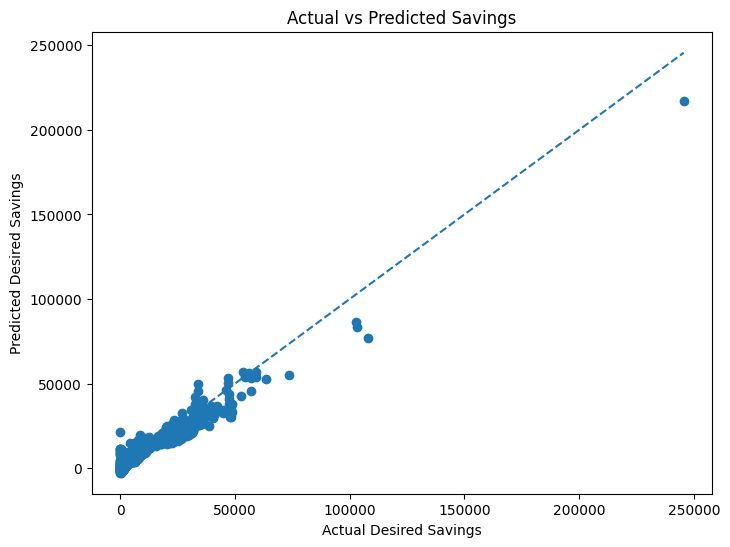

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Desired Savings")
plt.ylabel("Predicted Desired Savings")

plt.title("Actual vs Predicted Savings")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

VERIFY DATA LEAKAGE

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

x_train_processed = preprocessor.fit_transform(X_train)

rf_model.fit(x_train_processed, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
encoded_cat_features = preprocessor.named_transformers_["cat"]\
    .get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(encoded_cat_features)

In [ ]:
importance = rf_model.feature_importances_

In [ ]:
feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importance
})

In [ ]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [ ]:
print(feature_importance_df.head(15))

             Feature  Importance
0             Income    0.916465
4     Loan_Repayment    0.020462
3               Rent    0.009462
7          Transport    0.008871
11        Healthcare    0.008299
10         Utilities    0.007395
12         Education    0.004657
18  City_Tier_Tier_1    0.004588
13     Miscellaneous    0.003253
6          Groceries    0.002805
8         Eating_Out    0.002711
5          Insurance    0.002570
9      Entertainment    0.002539
1                Age    0.002465
2         Dependents    0.001366
